Importing DailyClimateDelhi Dataset

In [2]:
import zipfile
import pandas as pd

# 1. Defina o caminho completo onde o arquivo ZIP está guardado
caminho_zip = r"C:\Users\user\Downloads\archive (2).zip"

# 2. Abra o arquivo ZIP e leia os CSVs internamente
with zipfile.ZipFile(caminho_zip, 'r') as z:
    
    with z.open('DailyDelhiClimateTrain.csv') as f1:
        train_df = pd.read_csv(f1)
        
    with z.open('DailyDelhiClimateTest.csv') as f2:
        test_df = pd.read_csv(f2)

print(train_df.head())
print(test_df.head())

         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000
         date   meantemp   humidity  wind_speed  meanpressure
0  2017-01-01  15.913043  85.869565    2.743478     59.000000
1  2017-01-02  18.500000  77.222222    2.894444   1018.277778
2  2017-01-03  17.111111  81.888889    4.016667   1018.333333
3  2017-01-04  18.700000  70.050000    4.545000   1015.700000
4  2017-01-05  18.388889  74.944444    3.300000   1014.333333


Importing necessary libraries

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.optimizers import Adam

Data Analysis

<Axes: >

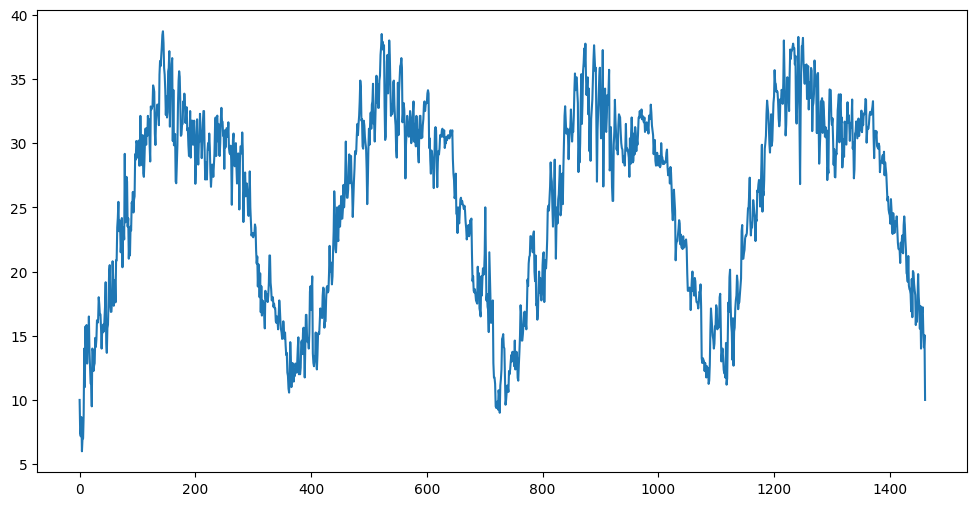

In [4]:
x = train_df['meantemp']
plt.figure(figsize=(12, 6))
x.plot()

<Axes: >

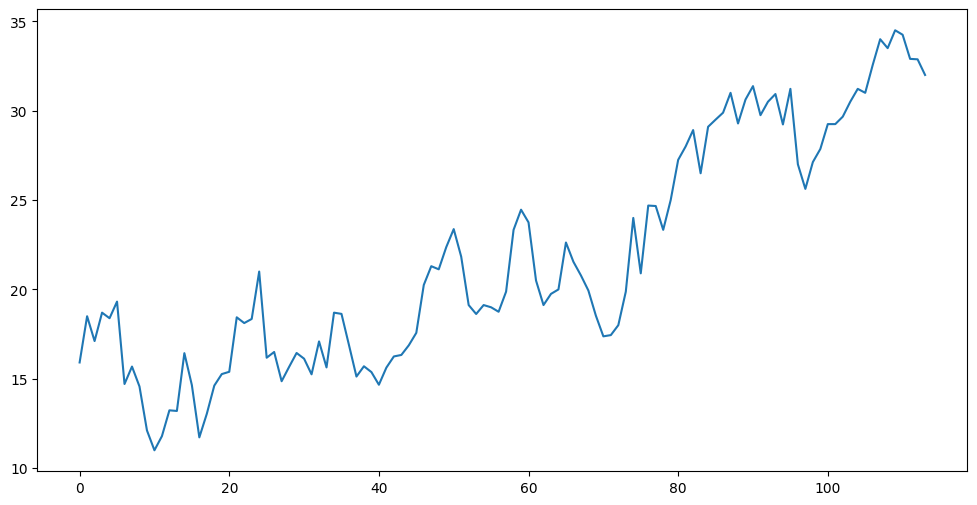

In [5]:
z = test_df['meantemp']
plt.figure(figsize=(12, 6))
z.plot()

First, solve the dataset for one input ("meantemp" feature), one output (same feature)

In [6]:
df_treino_temp = train_df[['date','meantemp']].copy()
df_treino_temp

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000
...,...,...
1457,2016-12-28,17.217391
1458,2016-12-29,15.238095
1459,2016-12-30,14.095238
1460,2016-12-31,15.052632


In [7]:
df_treino_temp['date'] = pd.to_datetime(df_treino_temp['date'])
df_treino_temp.set_index('date', inplace = True)
df_treino_temp.sort_index(inplace = True)
df_treino_temp.head()

,meantemp
date,
2013-01-01,10.000000
2013-01-02,7.400000
2013-01-03,7.166667
2013-01-04,8.666667
2013-01-05,6.000000


Checking for missing values

In [8]:
df_treino_temp.isnull().sum()

meantemp    0
dtype: int64

Creating Scaler for our input feature of the first model:

In [9]:
temp_scaler = MinMaxScaler(feature_range=(-1, 1))
df_treino_temp = temp_scaler.fit_transform(df_treino_temp)

Windowing (necessary for LSTM)

In [10]:
def df_to_X_y(df,window_size = 8):
  df_as_np = df
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [a for a in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i + window_size]
    y.append(label)
  return np.array(X), np.array(y)

In [11]:
X_train , y_train = df_to_X_y(df_treino_temp, window_size=8)
X_train.shape, y_train.shape

((1454, 8, 1), (1454, 1))

Creating our first model with LSTM

In [12]:
modelo1 = Sequential()
modelo1.add(InputLayer((8 ,1)))
modelo1.add(LSTM(30))
modelo1.add(Dense(10, 'relu'))
modelo1.add(Dense(1, 'linear'))

In [16]:
mm = ModelCheckpoint('modelo1/best_model.keras', save_best_only = True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

modelo1.compile(loss = 'MeanAbsoluteError', optimizer = 'Adam', metrics = ['MeanAbsoluteError'])
modelo1.fit(X_train, y_train, validation_split = 0.2 , epochs = 100, batch_size = 32, callbacks = [mm, lr_scheduler])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - MeanAbsoluteError: 0.0753 - loss: 0.0753 - val_MeanAbsoluteError: 0.0777 - val_loss: 0.0777 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0744 - loss: 0.0744 - val_MeanAbsoluteError: 0.0736 - val_loss: 0.0736 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0746 - loss: 0.0746 - val_MeanAbsoluteError: 0.0740 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0747 - loss: 0.0747 - val_MeanAbsoluteError: 0.0745 - val_loss: 0.0745 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MeanAbsoluteError: 0.0740 - loss: 0.0740 - val_MeanAbsoluteError: 0.0756 - val_loss: 0.0756 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MeanAbsoluteError: 0.0748 - loss: 0.0748 - val_MeanAbsoluteError: 0.0791 - val_loss: 0.0791 - learnin

Checking the results

In [17]:
df_teste_temp = test_df[['date','meantemp']].copy()

df_teste_temp['date'] = pd.to_datetime(df_teste_temp['date'])
df_teste_temp.set_index('date', inplace = True)
df_teste_temp.sort_index(inplace = True)
df_teste_temp.head()

,meantemp
date,
2017-01-01,15.913043
2017-01-02,18.500000
2017-01-03,17.111111
2017-01-04,18.700000
2017-01-05,18.388889


In [18]:
df_teste_temp = temp_scaler.transform(df_teste_temp)
x_test, y_test = df_to_X_y(df_teste_temp, window_size=5)

In [19]:
train_predictions = modelo1.predict(X_train).flatten()
train_results = pd.DataFrame(data = {'Train Predictions': train_predictions, 'Actuals': y_train.flatten()})
train_results

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Train Predictions,Actuals
0,-0.754451,-0.510917
1,-0.480055,-0.694323
2,-0.622263,-0.406114
3,-0.408757,-0.510917
4,-0.484134,-0.398836
...,...,...
1449,-0.334532,-0.314221
1450,-0.318864,-0.435226
1451,-0.422567,-0.505095
1452,-0.491282,-0.446564


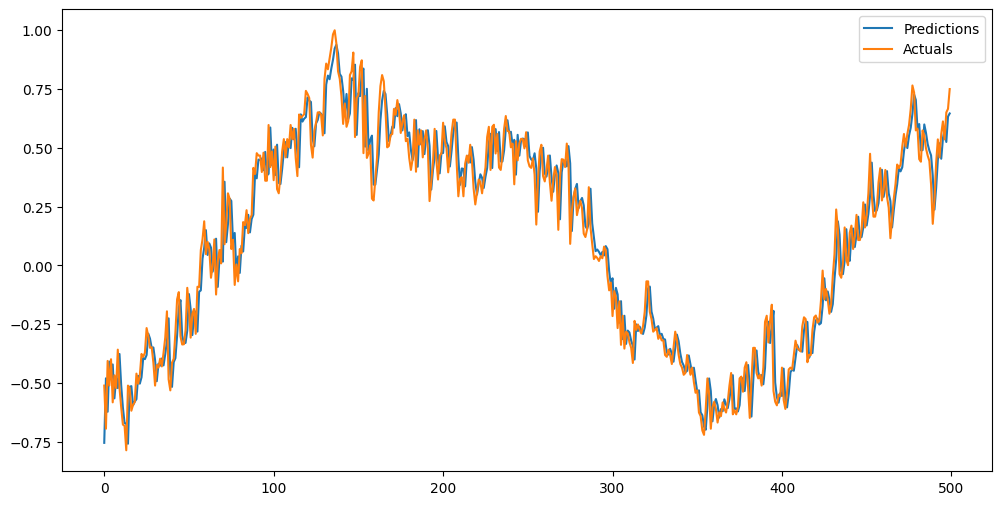

In [20]:
plt.figure(figsize = (12,6))
plt.plot(train_results['Train Predictions'][:500], label = 'Predictions')
plt.plot(train_results['Actuals'][:500], label = 'Actuals')
plt.legend()

Checking test score

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


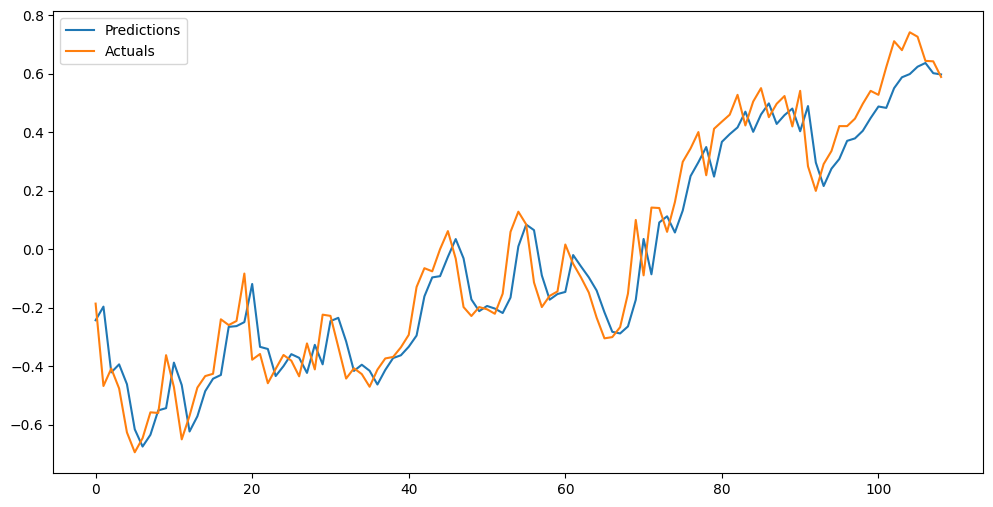

In [21]:
predictions = modelo1.predict(x_test).flatten()
actuals = y_test.flatten()

plt.figure(figsize=(12, 6))
plt.plot(predictions, label='Predictions')
plt.plot(actuals, label='Actuals')
plt.legend()


In [22]:
loss, mae = modelo1.evaluate(x_test, y_test)

print(f"MAE do Teste: {mae}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - MeanAbsoluteError: 0.0852 - loss: 0.0852  
MAE do Teste: 0.0852009654045105


Data analysis for model 2 , now we have 4 inputs and 1 outpu(which still is meantemp)

In [23]:
y_real = temp_scaler.inverse_transform(actuals.reshape(-1, 1))
y_pred = temp_scaler.inverse_transform(predictions.reshape(-1, 1))
new_df = pd.DataFrame({'Real': y_real.flatten(), 'Previsto': y_pred.flatten()})
new_df

,Real,Previsto
0,19.318182,18.388180
1,14.708333,19.149313
2,15.684211,15.470721
3,14.571429,15.919162
4,12.111111,14.810956
...,...,...
104,34.500000,32.162159
105,34.250000,32.573627
106,32.900000,32.782330
107,32.875000,32.211544


<Axes: >

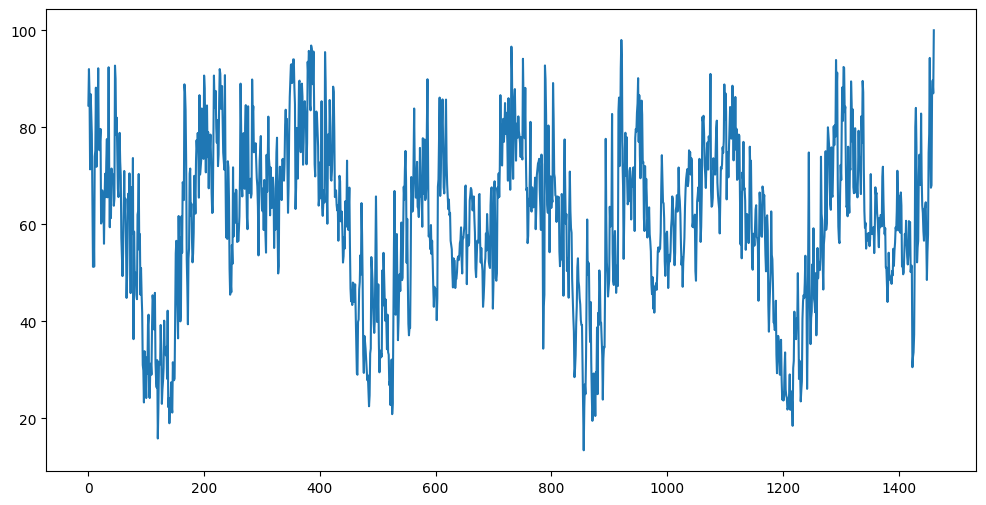

In [24]:
x = train_df['humidity']
plt.figure(figsize=(12, 6))
x.plot()

<Axes: >

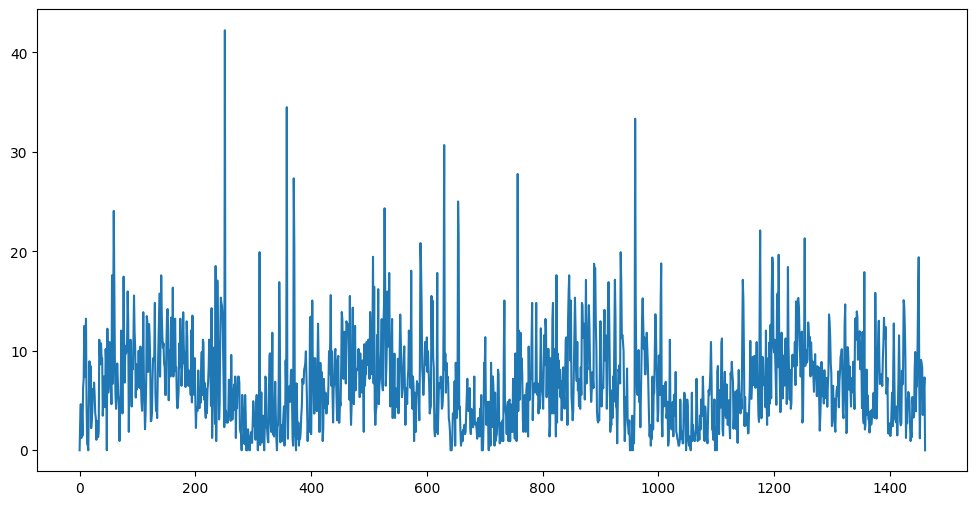

In [25]:
x = train_df['wind_speed']
plt.figure(figsize=(12, 6))
x.plot()

<Axes: >

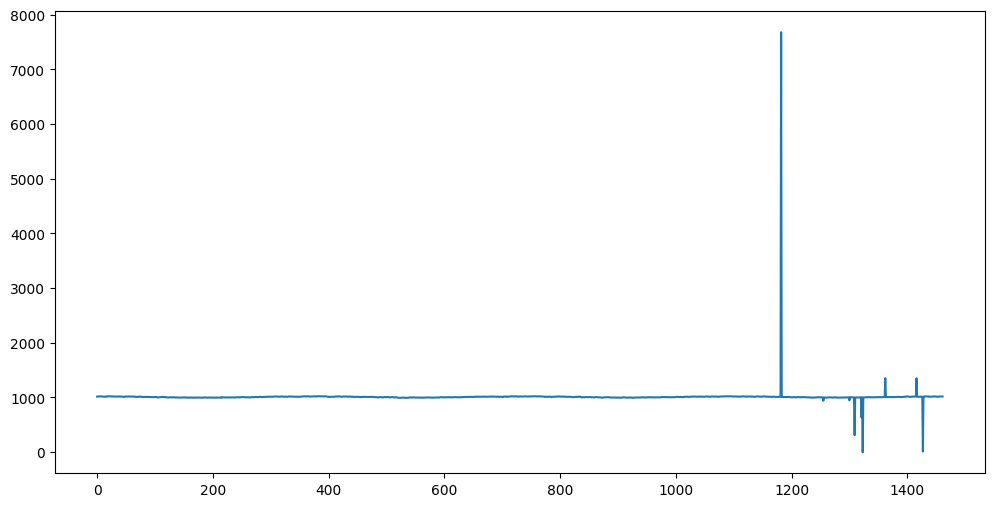

In [26]:
x = train_df['meanpressure']
plt.figure(figsize=(12, 6))
x.plot()

In [27]:
train_df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

There are no mising values

After taking a look at the data, makes sense to use MinMaxScaler for all of them providing better performance for the new model

Now let's turn the date into index

In [ ]:


train_df['date'] = pd.to_datetime(train_df['date'])
train_df.set_index('date', inplace = True)
train_df = train_df.sort_values(ascending = True, by = 'date')
train_df

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217
2016-12-29,15.238095,87.857143,6.000000,1016.904762
2016-12-30,14.095238,89.666667,6.266667,1017.904762


Scaling the features

In [31]:
tempscaler = MinMaxScaler(feature_range = (-1, 1))
humidityscaler = MinMaxScaler(feature_range = (-1, 1))
windscalers = MinMaxScaler(feature_range = (-1, 1))
meanpressurescaler = MinMaxScaler()

In [32]:
train_df['meantemp'] = tempscaler.fit_transform(train_df[['meantemp']])
train_df['humidity'] = humidityscaler.fit_transform(train_df[['humidity']])
train_df['wind_speed'] = windscalers.fit_transform(train_df[['wind_speed']])
train_df['meanpressure'] = meanpressurescaler.fit_transform(train_df[['meanpressure']])

Windowing

In [33]:
def X_to_y_multivariable(df,window_size = 8):
  df_as_np = df
  X = []
  y = []
  for i in range(len(df)-window_size):
    row = df.iloc[i: i + window_size].values
    label = df.iloc[i + window_size, 0]
    X.append(row)
    y.append(label)
  return np.array(X), np.array(y)

In [34]:
features = ['meantemp','humidity','wind_speed','meanpressure']


X_train2, y_train2 = X_to_y_multivariable(train_df[features], window_size = 10)
print(X_train2.shape)
print(y_train2.shape)

(1452, 10, 4)
(1452,)


Creating and training the new LSTM model

In [35]:
modelo2 = Sequential()
modelo2.add(InputLayer((10, 4)))
modelo2.add(LSTM(32))
modelo2.add(Dense(32),'relu')
modelo2.add(Dense(1))

In [36]:
mm = ModelCheckpoint('modelo1/best_model.keras', save_best_only = True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

modelo2.compile(loss = 'MeanAbsoluteError', optimizer = 'Adam', metrics = ['MeanAbsoluteError'])
historico = modelo2.fit(X_train2, y_train2, validation_split = 0.2 , epochs = 100, batch_size = 32, callbacks = [mm, lr_scheduler])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - MeanAbsoluteError: 0.2177 - loss: 0.2177 - val_MeanAbsoluteError: 0.0970 - val_loss: 0.0970 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - MeanAbsoluteError: 0.0981 - loss: 0.0981 - val_MeanAbsoluteError: 0.0929 - val_loss: 0.0929 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - MeanAbsoluteError: 0.0927 - loss: 0.0927 - val_MeanAbsoluteError: 0.0872 - val_loss: 0.0872 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0874 - loss: 0.0874 - val_MeanAbsoluteError: 0.0863 - val_loss: 0.0863 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0878 - loss: 0.0878 - val_MeanAbsoluteError: 0.0857 - val_loss: 0.0857 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0836 - loss: 0.0836 - val_MeanAbsoluteError: 0.0857 - val_loss: 0.0857 - learnin

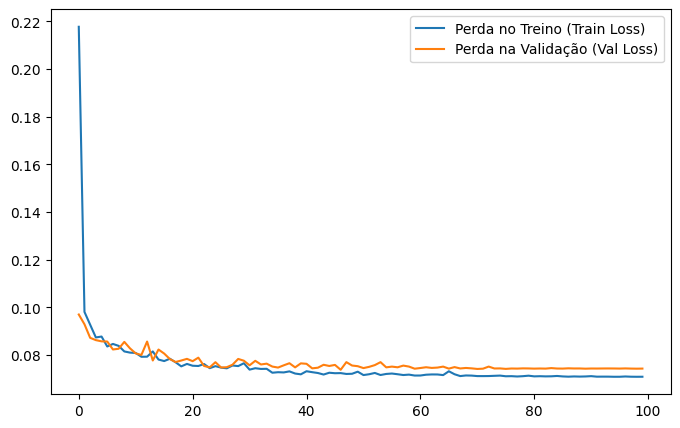

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(historico.history['loss'], label='Perda no Treino (Train Loss)')
plt.plot(historico.history['val_loss'], label='Perda na Validação (Val Loss)')
plt.legend()

Trained sucessufully, probably no over or underfitting. 

Proceed to evaluate the model by plot and MAE

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/stepWARNING:tensorflow:5 out of the last 54 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000022AEC117240> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


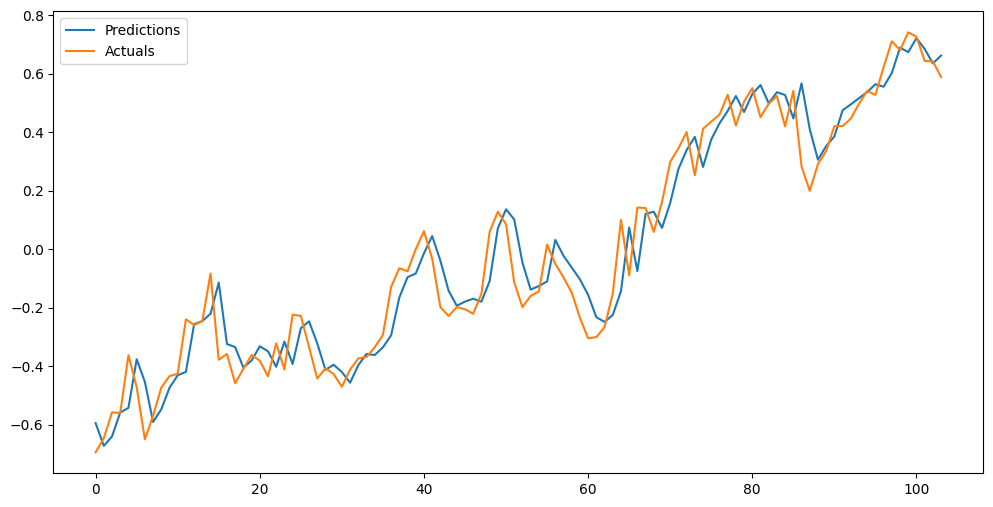

In [39]:

test_df['date'] = pd.to_datetime(test_df['date'])
test_df.set_index('date', inplace = True)
test_df.sort_index(inplace = True)

test_df['meantemp'] = tempscaler.transform(test_df[['meantemp']])
test_df['humidity'] = humidityscaler.transform(test_df[['humidity']])
test_df['wind_speed'] = windscalers.transform(test_df[['wind_speed']])
test_df['meanpressure'] = meanpressurescaler.transform(test_df[['meanpressure']])

x_test, y_test = X_to_y_multivariable(test_df[features], window_size=10)

predictions = modelo2.predict(x_test).flatten()
actuals = y_test.flatten()

plt.figure(figsize=(12, 6))
plt.plot(predictions, label='Predictions')
plt.plot(actuals, label='Actuals')
plt.legend()

In [40]:
loss, mae = modelo2.evaluate(x_test, y_test)

print(f"MAE do Teste: {mae}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - MeanAbsoluteError: 0.0769 - loss: 0.0769 
MAE do Teste: 0.07685132324695587


Next task: a model with multiple inputs and multiples outputs.

We will now precidt all features at once

Windowing (mimo = multiple inputs multiple outputs)

In [41]:
def X_to_y_mimo(df,window_size = 8):
  df_as_np = df
  X = []
  y = []
  for i in range(len(df)-window_size):
    row = df.iloc[i: i + window_size].values
    label = df.iloc[i + window_size]
    X.append(row)
    y.append(label)
  return np.array(X), np.array(y)

In [42]:
features = ['meantemp','humidity','wind_speed','meanpressure']


X_train3, y_train3 = X_to_y_mimo(train_df[features], window_size = 10)
print(X_train3.shape)
print(y_train3.shape)

(1452, 10, 4)
(1452, 4)


Creating and training the third model

In [43]:
modelo3 = Sequential()
modelo3.add(InputLayer((10, 4)))
modelo3.add(LSTM(32))
modelo3.add(Dense(32),'relu')
modelo3.add(Dense(4))

In [45]:
mm = ModelCheckpoint('modelo1/best_model.keras', save_best_only = True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

modelo3.compile(loss = 'MeanAbsoluteError', optimizer = 'Adam', metrics = ['MeanAbsoluteError'])
historico = modelo3.fit(X_train3, y_train3, validation_split = 0.2 , epochs = 100, batch_size = 32, callbacks = [mm, lr_scheduler])

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - MeanAbsoluteError: 0.0868 - loss: 0.0868 - val_MeanAbsoluteError: 0.0841 - val_loss: 0.0841 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0853 - loss: 0.0853 - val_MeanAbsoluteError: 0.0836 - val_loss: 0.0836 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0858 - loss: 0.0858 - val_MeanAbsoluteError: 0.0852 - val_loss: 0.0852 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - MeanAbsoluteError: 0.0863 - loss: 0.0863 - val_MeanAbsoluteError: 0.0850 - val_loss: 0.0850 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0859 - loss: 0.0859 - val_MeanAbsoluteError: 0.0835 - val_loss: 0.0835 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MeanAbsoluteError: 0.0861 - loss: 0.0861 - val_MeanAbsoluteError: 0.0846 - val_loss: 0.0846 - learning

Final evaluation

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


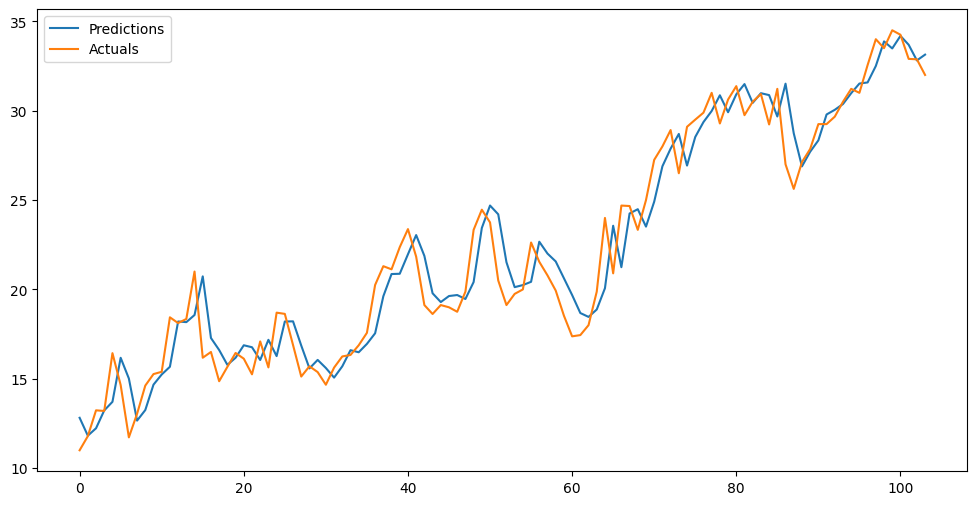

In [46]:
from sklearn.metrics import mean_absolute_error
x_test3, y_test3 = X_to_y_mimo(test_df[features], window_size=10)
predictions = modelo3.predict(x_test3)

mae_temp = mean_absolute_error(y_test3[:, 0], predictions[:, 0])
mae_humidity = mean_absolute_error(y_test3[:, 1], predictions[:, 1])
mae_wind = mean_absolute_error(y_test3[:, 2], predictions[:, 2])
mae_pressure = mean_absolute_error(y_test3[:, 3], predictions[:, 3])


temp_pred = temp_scaler.inverse_transform(predictions[:, 0].reshape(-1, 1))
humidity_pred = humidityscaler.inverse_transform(predictions[:, 1].reshape(-1, 1))
wind_pred = windscalers.inverse_transform(predictions[:, 2].reshape(-1, 1))
pressure_pred = meanpressurescaler.inverse_transform(predictions[:, 3].reshape(-1, 1))


actual_temp = temp_scaler.inverse_transform(y_test3[:, 0].reshape(-1, 1))


plt.figure(figsize=(12, 6))
plt.plot(temp_pred, label='Predictions')
plt.plot(actual_temp, label='Actuals')
plt.legend()
plt.show()


In [47]:
print(f"MAE do Teste temperatura: {mae_temp}")
print(f"MAE do Teste umidade: {mae_humidity}")
print(f"MAE do Teste vento: {mae_wind}")
print(f"MAE do Teste pressão: {mae_pressure}")

MAE do Teste temperatura: 0.07603633423405064
MAE do Teste umidade: 0.11708018745505142
MAE do Teste vento: 0.13299690288115554
MAE do Teste pressão: 0.00047388456295953635


The best model was the third not did only was the best onde predicting the main target (temperature) but also did such a good job with the other features